In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay

Choisir le module à utiliser:

In [2]:
# from nn_cours import Linear, ReLU, Logistic, Tanh, Softmax, SGDWithMomentum, MSELoss, CrossEntropyLoss, Tensor, Sequential
from nn import Linear, ReLU, Logistic, Tanh, Softmax, SGDWithMomentum, MSELoss, CrossEntropyLoss, Tensor, Sequential, SGD

## Regression

### Génération de données pour tester

In [3]:
def f(x):
    return np.exp(-2 * x) * np.sin(6 * x)

In [4]:
n = 1000
X = np.random.uniform(-1., 1., (n, 1))
Y = f(X) + np.random.normal(0., 0.2, (n, 1))

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [6]:
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(Y_train)

In [7]:
X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)
Y_train = y_scaler.transform(Y_train)
Y_test = y_scaler.transform(Y_test)

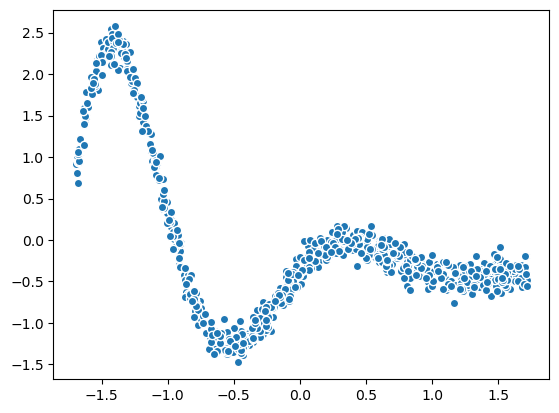

In [8]:
plt.scatter(X_train, Y_train, edgecolor="w");

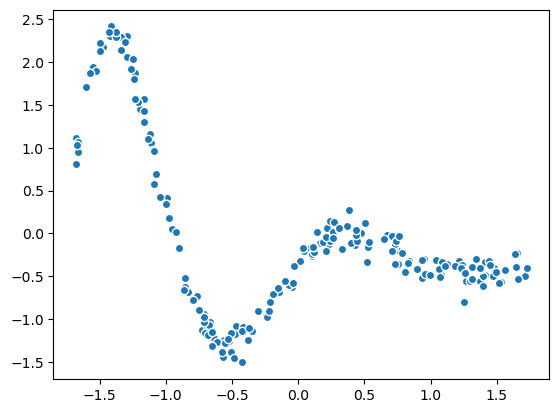

In [9]:
plt.scatter(X_test, Y_test, edgecolor="w");

In [10]:
X_train = Tensor(X_train)
X_test = Tensor(X_test)
Y_train = Tensor(Y_train)
Y_test = Tensor(Y_test)

### Création du modèle

In [12]:
model = Sequential([
    Linear(1, 8, init="xavier", gain=5/3),
    Tanh(),
    Linear(8, 1, init="xavier"),
])

In [13]:
model[0].weight, model[0].bias

(array([[-0.27794026, -0.13686015, -0.2905831 ,  0.24263065, -0.92863251,
          0.30075779,  1.32804811,  0.0073105 ]]),
 array([[0., 0., 0., 0., 0., 0., 0., 0.]]))

In [14]:
model[2].weight, model[2].bias

(array([[ 1.07115595],
        [-0.47844473],
        [ 0.61277566],
        [ 0.26573141],
        [-0.56569209],
        [ 0.14597038],
        [-0.62713678],
        [ 0.86532113]]),
 array([[0.]]))

### Optimiseur et fonction de coût

In [16]:
model.parameters()

[array([[-0.27794026, -0.13686015, -0.2905831 ,  0.24263065, -0.92863251,
          0.30075779,  1.32804811,  0.0073105 ]]),
 array([[0., 0., 0., 0., 0., 0., 0., 0.]]),
 array([[ 1.07115595],
        [-0.47844473],
        [ 0.61277566],
        [ 0.26573141],
        [-0.56569209],
        [ 0.14597038],
        [-0.62713678],
        [ 0.86532113]]),
 array([[0.]])]

In [17]:
optim = SGDWithMomentum(model.parameters(), learning_rate=0.1, beta1=0.9)
loss = MSELoss()

In [18]:
def batch(n, batch_size=128):
    indices = np.array(range(n))
    np.random.shuffle(indices)
    i = 0
    while i < n:
        yield indices[i: i + batch_size]
        i += batch_size

In [25]:
epochs = 100
batch_size = 32

# Boucle sur les époques
for i in range(epochs):

    # Boucle sur les batchs
    for indices in batch(X_train.shape[0], batch_size):

        # Données d'entraînement pour le batch
        X_ = X_train[indices]
        Y_ = Y_train[indices]

        # Passe avant
        Yhat_ = model.forward(X_)
        mse = loss(Yhat_, Y_)

        # Rétro-propagation
        grad = loss.backward()
        model.backward(grad)

        # Optimisation
        optim.step()

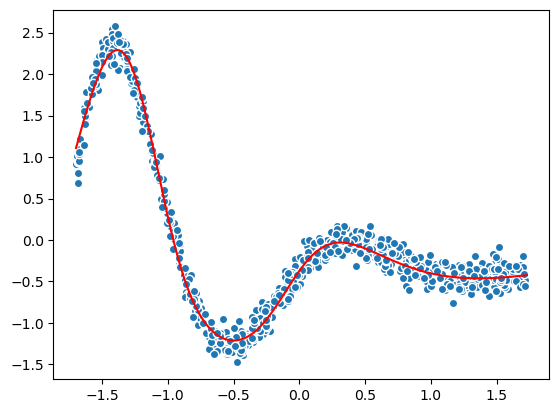

In [26]:
Xi = x_scaler.transform(np.linspace(-1, 1, 200).reshape(-1, 1))
Yh = model(Tensor((Xi)))
plt.scatter(X_train, Y_train, edgecolor="w")
plt.plot(Xi, Yh, zorder=10, color="r");

## Classification

### Génération de données pour tester

In [27]:
n = 200
m = 3
X, Y = make_classification(n_samples=n, n_features=2, n_classes=m, n_redundant=0, n_informative=2, n_clusters_per_class=1, random_state=23)

In [28]:
onehot = np.zeros((n, m))
onehot[np.arange(n), Y] = 1.0
Y = onehot

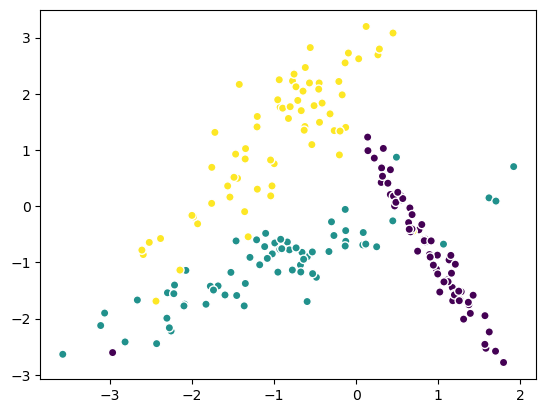

In [29]:
plt.scatter(X[:,0], X[:,1], c=Y.argmax(axis=1), edgecolor="w");

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [31]:
x_scaler = StandardScaler().fit(X_train)

In [32]:
X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)

In [33]:
X_train = Tensor(X_train)
X_test = Tensor(X_test)
Y_train = Tensor(Y_train)
Y_test = Tensor(Y_test)

In [35]:
model = Sequential([
    Linear(2, 32, init="kaiming"),
    ReLU(),
    Linear(32, 3),
])

In [36]:
optim = SGDWithMomentum(model.parameters(), learning_rate=0.1, beta1=0.9)
loss = CrossEntropyLoss()

In [37]:
epochs = 1000
batch_size = 32

# Boucle sur les époques
for i in range(epochs):

    # Boucle sur les batchs
    for indices in batch(X_train.shape[0], batch_size):

        # Données d'entraînement pour le batch
        X_ = X_train[indices]
        Y_ = Y_train[indices]

        # Passe avant
        Yhat_ = model(X_)
        mse = loss(Yhat_, Y_)

        # Rétro-propagation
        grad = loss.backward()
        model.backward(grad)

        # Optimisation
        optim.step()

In [38]:
clf = Sequential([
    model,
    Softmax()  # on rajoute le softmax pour calculer des probabilités
])

In [39]:
Yh = clf(X_test)

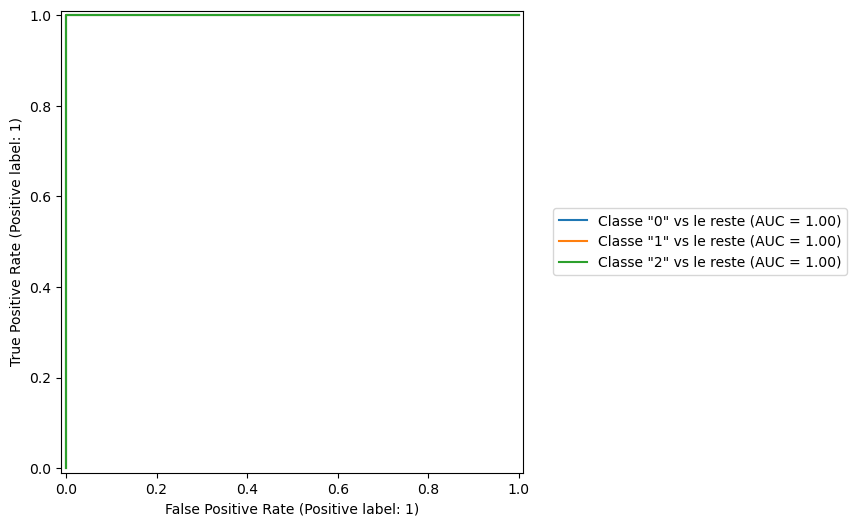

In [40]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(3):
    RocCurveDisplay.from_predictions(y_true=Y_test.data[:,i], y_score=Yh.data[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

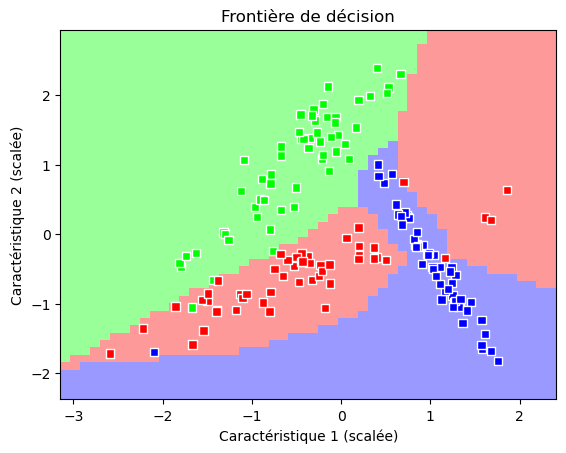

In [41]:
# Résolution de la grille
s = 50

# On crée la grille directement aux bornes des données SCALÉES
x1_min, x1_max = X_train.data[:, 0].min() - 0.5, X_train.data[:, 0].max() + 0.5
x2_min, x2_max = X_train.data[:, 1].min() - 0.5, X_train.data[:, 1].max() + 0.5

X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, s), np.linspace(x2_min, x2_max, s))

# Calcul
Xi = np.stack((X1.ravel(), X2.ravel())).T
Yi = clf(Tensor(Xi))
Ci = Yi.data.argmax(axis=1).reshape((s, s))

# Visualisation
plt.pcolormesh(X1, X2, Ci, cmap='brg', alpha=0.4, shading='auto')
plt.scatter(X_train.data[:,0], X_train.data[:,1], c=Y_train.data.argmax(axis=1), marker="s", cmap='brg', edgecolor="w")
plt.xlabel("Caractéristique 1 (scalée)")
plt.ylabel("Caractéristique 2 (scalée)")
plt.title("Frontière de décision");